In [1]:
!pip install -q pandas openpyxl transformers accelerate torch matplotlib scikit-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import gc
from google.colab import files

from transformers import AutoTokenizer, AutoModelForCausalLM

In [3]:
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU detected. Go to Runtime > Change runtime type > T4 GPU.")

CUDA available: True
GPU: Tesla T4


In [4]:
uploaded = files.upload()

filename = list(uploaded.keys())[0]
print("Uploaded file:", filename)

if filename.endswith(".csv"):
    df = pd.read_csv(filename)
elif filename.endswith(".xlsx"):
    df = pd.read_excel(filename)
else:
    raise ValueError("Please upload a CSV or Excel file.")

df.head()

Saving nejm_cases_combined_task2.xlsx to nejm_cases_combined_task2.xlsx
Uploaded file: nejm_cases_combined_task2.xlsx


,case_id,NEJM_link,case_summary,correct_diagnosis,diagnosis_short_label,key_findings,notes_for_benchmarking
0,Case 1,https://www.nejm.org/doi/full/10.1056/NEJMcpc2...,A 22-year-old previously healthy man presented...,Erysipelothrix rhusiopathiae infection,Cutaneous Erysipelothrix rhusiopathiae infecti...,Acute painful violaceous bullae; lymphangitic ...,Difficult because it resembles common cellulit...
1,Case 2,https://www.nejm.org/doi/full/10.1056/NEJMcpc1...,A 47-year-old woman with a history of malignan...,Pulmonary histoplasmosis,Histoplasma capsulatum pulmonary infection / p...,Prior metastatic melanoma treated with pembrol...,Difficult because metastatic melanoma recurren...
2,Case 3,https://www.nejm.org/doi/full/10.1056/NEJMcpc1...,A 53-year-old woman originally from Ivory Coas...,Human immunodeficiency virus type 2 infection ...,HIV-2 infection with cerebral toxoplasmosis,Progressive headache and ataxia; major weight ...,Difficult because HIV results appear contradic...
3,Case 4,https://www.nejm.org/doi/full/10.1056/NEJMcpc2...,"A 63-year-old man was evaluated for fever, con...",Borrelia miyamotoi infection,Borrelia miyamotoi meningoencephalitis,Rituximab immunosuppression; subacute meningoe...,Difficult because common Lyme and other infect...
4,Case 5,https://www.nejm.org/doi/full/10.1056/NEJMcpc2...,A 29-month-old boy was transferred after a pre...,Vitamin D deficiency,Nutritional vitamin D deficiency with rickets ...,Toddler with seizure; severe hypocalcemia; low...,Tests whether the model connects hypocalcemic ...


In [5]:
required_columns = [
    "case_id",
    "NEJM_link",
    "case_summary",
    "correct_diagnosis",
    "diagnosis_short_label"
]

for col in required_columns:
    if col not in df.columns:
        raise ValueError(f"Missing required column: {col}")

print("Dataset loaded successfully.")
print("Number of cases:", len(df))

df[["case_id", "case_summary", "correct_diagnosis"]].head()

Dataset loaded successfully.
Number of cases: 10


,case_id,case_summary,correct_diagnosis
0,Case 1,A 22-year-old previously healthy man presented...,Erysipelothrix rhusiopathiae infection
1,Case 2,A 47-year-old woman with a history of malignan...,Pulmonary histoplasmosis
2,Case 3,A 53-year-old woman originally from Ivory Coas...,Human immunodeficiency virus type 2 infection ...
3,Case 4,"A 63-year-old man was evaluated for fever, con...",Borrelia miyamotoi infection
4,Case 5,A 29-month-old boy was transferred after a pre...,Vitamin D deficiency


In [6]:
model_input_df = df[["case_id", "NEJM_link", "case_summary"]].copy()

model_input_df.head()

,case_id,NEJM_link,case_summary
0,Case 1,https://www.nejm.org/doi/full/10.1056/NEJMcpc2...,A 22-year-old previously healthy man presented...
1,Case 2,https://www.nejm.org/doi/full/10.1056/NEJMcpc1...,A 47-year-old woman with a history of malignan...
2,Case 3,https://www.nejm.org/doi/full/10.1056/NEJMcpc1...,A 53-year-old woman originally from Ivory Coas...
3,Case 4,https://www.nejm.org/doi/full/10.1056/NEJMcpc2...,"A 63-year-old man was evaluated for fever, con..."
4,Case 5,https://www.nejm.org/doi/full/10.1056/NEJMcpc2...,A 29-month-old boy was transferred after a pre...


In [7]:
MODEL_1_NAME = "Qwen/Qwen2.5-1.5B-Instruct"
MODEL_2_NAME = "Qwen/Qwen2.5-3B-Instruct"

print("Model 1:", MODEL_1_NAME)
print("Model 2:", MODEL_2_NAME)

Model 1: Qwen/Qwen2.5-1.5B-Instruct
Model 2: Qwen/Qwen2.5-3B-Instruct


In [8]:
def build_diagnostic_prompt(case_summary):
    prompt = f"""
You are completing an academic benchmark of AI diagnostic reasoning using a clinical case summary.

Task:
Identify the most likely diagnosis from the case summary.

Return the answer in this exact format:

Most likely diagnosis:
Top 3 differential diagnoses:
1.
2.
3.
Short justification:
Confidence level:

Rules:
- Use only the case summary.
- Do not copy the case summary.
- Do not say this is not medical advice.
- Give a specific diagnosis, not a broad symptom category.

Clinical case summary:
{case_summary}
"""
    return prompt

In [9]:
def load_causal_llm(model_name):
    print(f"Loading model: {model_name}")

    tokenizer = AutoTokenizer.from_pretrained(
        model_name,
        trust_remote_code=True
    )

    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
        device_map="auto",
        trust_remote_code=True,
        low_cpu_mem_usage=True
    )

    model.eval()

    return tokenizer, model

In [10]:
def generate_diagnosis_direct(tokenizer, model, prompt, max_new_tokens=250):
    messages = [
        {
            "role": "system",
            "content": "You are an academic clinical diagnostic reasoning assistant."
        },
        {
            "role": "user",
            "content": prompt
        }
    ]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=3072
    ).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            num_beams=1,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id
        )

    generated_tokens = outputs[0][inputs["input_ids"].shape[-1]:]
    response = tokenizer.decode(generated_tokens, skip_special_tokens=True)

    return response.strip()

In [11]:
def run_model_on_cases(model_name, data):
    tokenizer, model = load_causal_llm(model_name)

    outputs = []

    for index, row in data.iterrows():
        case_id = row["case_id"]
        case_summary = row["case_summary"]

        print(f"Running {model_name} on {case_id}...")

        prompt = build_diagnostic_prompt(case_summary)
        response = generate_diagnosis_direct(tokenizer, model, prompt)

        outputs.append(response)

    del tokenizer
    del model
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return outputs

In [12]:
df["model1_name"] = MODEL_1_NAME
df["model1_output"] = run_model_on_cases(MODEL_1_NAME, model_input_df)

df[["case_id", "model1_output"]]

Loading model: Qwen/Qwen2.5-1.5B-Instruct


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Running Qwen/Qwen2.5-1.5B-Instruct on Case 1...
Running Qwen/Qwen2.5-1.5B-Instruct on Case 2...
Running Qwen/Qwen2.5-1.5B-Instruct on Case 3...
Running Qwen/Qwen2.5-1.5B-Instruct on Case 4...
Running Qwen/Qwen2.5-1.5B-Instruct on Case 5...
Running Qwen/Qwen2.5-1.5B-Instruct on Case 6...
Running Qwen/Qwen2.5-1.5B-Instruct on Case 7...
Running Qwen/Qwen2.5-1.5B-Instruct on Case 8...
Running Qwen/Qwen2.5-1.5B-Instruct on Case 9...
Running Qwen/Qwen2.5-1.5B-Instruct on Case 10...


,case_id,model1_output
0,Case 1,Most likely diagnosis:\nDermatofibrosarcoma pr...
1,Case 2,Most likely diagnosis:\nPrimary pulmonary tube...
2,Case 3,Most likely diagnosis:\nHIV encephalopathy\n\n...
3,Case 4,Most likely diagnosis:\nPrimary Sjögren's synd...
4,Case 5,Most likely diagnosis:\nRickets\n\nTop 3 diffe...
5,Case 6,Most likely diagnosis:\nOptic nerve glioma\n\n...
6,Case 7,Most likely diagnosis:\nLyme disease\n\nTop 3 ...
7,Case 8,Most likely diagnosis:\nChronic obstructive pu...
8,Case 9,Most likely diagnosis:\nPneumonia due to Strep...
9,Case 10,Most likely diagnosis:\nMultiple sclerosis (MS...


In [13]:
df.to_csv("checkpoint_after_model1_qwen.csv", index=False)
files.download("checkpoint_after_model1_qwen.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [14]:
df["model2_name"] = MODEL_2_NAME
df["model2_output"] = run_model_on_cases(MODEL_2_NAME, model_input_df)

df[["case_id", "model2_output"]]

Loading model: Qwen/Qwen2.5-3B-Instruct


config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Running Qwen/Qwen2.5-3B-Instruct on Case 1...
Running Qwen/Qwen2.5-3B-Instruct on Case 2...
Running Qwen/Qwen2.5-3B-Instruct on Case 3...
Running Qwen/Qwen2.5-3B-Instruct on Case 4...
Running Qwen/Qwen2.5-3B-Instruct on Case 5...
Running Qwen/Qwen2.5-3B-Instruct on Case 6...
Running Qwen/Qwen2.5-3B-Instruct on Case 7...
Running Qwen/Qwen2.5-3B-Instruct on Case 8...
Running Qwen/Qwen2.5-3B-Instruct on Case 9...
Running Qwen/Qwen2.5-3B-Instruct on Case 10...


,case_id,model2_output
0,Case 1,Most likely diagnosis:\nDeep fungal infection ...
1,Case 2,Most likely diagnosis:\nPulmonary tuberculosis...
2,Case 3,Most likely diagnosis:\nProgressive Multifocal...
3,Case 4,Most likely diagnosis:\nSubacute sclerosing pa...
4,Case 5,Most likely diagnosis:\nEhlers-Danlos Syndrome...
5,Case 6,Most likely diagnosis:\nMalignant orbital tumo...
6,Case 7,Most likely diagnosis:\nJuvenile Rheumatoid Ar...
7,Case 8,Most likely diagnosis:\nGranulomatous disease ...
8,Case 9,Most likely diagnosis:\nAcute Respiratory Dist...
9,Case 10,Most likely diagnosis:\nGuillain-Barré Syndrom...


In [15]:
review_df = df[
    [
        "case_id",
        "correct_diagnosis",
        "diagnosis_short_label",
        "model1_output",
        "model2_output"
    ]
]

review_df

,case_id,correct_diagnosis,diagnosis_short_label,model1_output,model2_output
0,Case 1,Erysipelothrix rhusiopathiae infection,Cutaneous Erysipelothrix rhusiopathiae infecti...,Most likely diagnosis:\nDermatofibrosarcoma pr...,Most likely diagnosis:\nDeep fungal infection ...
1,Case 2,Pulmonary histoplasmosis,Histoplasma capsulatum pulmonary infection / p...,Most likely diagnosis:\nPrimary pulmonary tube...,Most likely diagnosis:\nPulmonary tuberculosis...
2,Case 3,Human immunodeficiency virus type 2 infection ...,HIV-2 infection with cerebral toxoplasmosis,Most likely diagnosis:\nHIV encephalopathy\n\n...,Most likely diagnosis:\nProgressive Multifocal...
3,Case 4,Borrelia miyamotoi infection,Borrelia miyamotoi meningoencephalitis,Most likely diagnosis:\nPrimary Sjögren's synd...,Most likely diagnosis:\nSubacute sclerosing pa...
4,Case 5,Vitamin D deficiency,Nutritional vitamin D deficiency with rickets ...,Most likely diagnosis:\nRickets\n\nTop 3 diffe...,Most likely diagnosis:\nEhlers-Danlos Syndrome...
5,Case 6,Systemic primary amyloidosis,Systemic AL amyloidosis / primary amyloidosis,Most likely diagnosis:\nOptic nerve glioma\n\n...,Most likely diagnosis:\nMalignant orbital tumo...
6,Case 7,Inflammatory bowel disease (Crohn’s disease),Crohn’s disease,Most likely diagnosis:\nLyme disease\n\nTop 3 ...,Most likely diagnosis:\nJuvenile Rheumatoid Ar...
7,Case 8,Aspiration pneumonia,Aspiration pneumonia / diffuse aspiration bron...,Most likely diagnosis:\nChronic obstructive pu...,Most likely diagnosis:\nGranulomatous disease ...
8,Case 9,Granulomatosis with polyangiitis,ANCA-associated vasculitis / granulomatosis wi...,Most likely diagnosis:\nPneumonia due to Strep...,Most likely diagnosis:\nAcute Respiratory Dist...
9,Case 10,Sarcoidosis,Sarcoidosis with ocular and neurologic involve...,Most likely diagnosis:\nMultiple sclerosis (MS...,Most likely diagnosis:\nGuillain-Barré Syndrom...


In [16]:
df.to_csv("qwen_two_model_raw_predictions.csv", index=False)
files.download("qwen_two_model_raw_predictions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:
scored_df = df.copy()

scored_df["model1_score"] = [0, 0, 0, 0, 0.5, 0, 0, 0, 0, 0]
scored_df["model1_top3_correct"] = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

scored_df["model2_score"] = [0, 0.5, 0.5, 0, 0.5, 0, 0, 0, 0.5, 0]
scored_df["model2_top3_correct"] = [0, 0, 0, 0, 1, 0, 0, 0, 0, 0]

scored_df["qualitative_notes"] = [
    "Both Qwen models missed the zoonotic Erysipelothrix diagnosis. Model 1 predicted contact dermatitis, while Model 2 predicted deep fungal infection.",
    "Model 1 predicted pulmonary sarcoidosis. Model 2 selected tuberculosis but discussed fungal pneumonia and histoplasmosis in the justification, so partial credit was given.",
    "Model 1 predicted hemorrhagic stroke. Model 2 recognised an HIV-associated CNS process but missed HIV-2 infection and cerebral toxoplasmosis, so partial credit was given.",
    "Both Qwen models missed Borrelia miyamotoi infection. Model 1 favoured Sjögren's syndrome, while Model 2 favoured PML, neurocysticercosis, or cryptococcal meningitis.",
    "Model 1 recognised a rickets-type process but incorrectly selected vitamin D toxicity. Model 2 selected Ehlers-Danlos syndrome but included vitamin D deficiency in the top 3, so partial credit was given.",
    "Both Qwen models missed systemic primary amyloidosis and focused on orbital malignancy or orbital inflammatory disease.",
    "Both Qwen models missed Crohn's disease and were distracted by tick exposure and infectious causes.",
    "Both Qwen models missed aspiration pneumonia and were distracted by immunosuppression and positive fungal markers.",
    "Model 1 predicted pulmonary embolism. Model 2 recognised a broad vasculitic/systemic inflammatory pattern but selected HSP rather than granulomatosis with polyangiitis, so partial credit was given.",
    "Both Qwen models missed sarcoidosis and were distracted by tuberculosis exposure and neurological involvement."
]

scored_df[
    [
        "case_id",
        "correct_diagnosis",
        "model1_score",
        "model1_top3_correct",
        "model2_score",
        "model2_top3_correct",
        "qualitative_notes"
    ]
]

,case_id,correct_diagnosis,model1_score,model1_top3_correct,model2_score,model2_top3_correct,qualitative_notes
0,Case 1,Erysipelothrix rhusiopathiae infection,0.0,0,0.0,0,Both Qwen models missed the zoonotic Erysipelo...
1,Case 2,Pulmonary histoplasmosis,0.0,0,0.5,0,Model 1 predicted pulmonary sarcoidosis. Model...
2,Case 3,Human immunodeficiency virus type 2 infection ...,0.0,0,0.5,0,Model 1 predicted hemorrhagic stroke. Model 2 ...
3,Case 4,Borrelia miyamotoi infection,0.0,0,0.0,0,Both Qwen models missed Borrelia miyamotoi inf...
4,Case 5,Vitamin D deficiency,0.5,0,0.5,1,Model 1 recognised a rickets-type process but ...
5,Case 6,Systemic primary amyloidosis,0.0,0,0.0,0,Both Qwen models missed systemic primary amylo...
6,Case 7,Inflammatory bowel disease (Crohn’s disease),0.0,0,0.0,0,Both Qwen models missed Crohn's disease and we...
7,Case 8,Aspiration pneumonia,0.0,0,0.0,0,Both Qwen models missed aspiration pneumonia a...
8,Case 9,Granulomatosis with polyangiitis,0.0,0,0.5,0,Model 1 predicted pulmonary embolism. Model 2 ...
9,Case 10,Sarcoidosis,0.0,0,0.0,0,Both Qwen models missed sarcoidosis and were d...


In [18]:
model1_average_score = scored_df["model1_score"].mean()
model2_average_score = scored_df["model2_score"].mean()

model1_exact_accuracy = (scored_df["model1_score"] == 1).mean()
model2_exact_accuracy = (scored_df["model2_score"] == 1).mean()

model1_top3_accuracy = scored_df["model1_top3_correct"].mean()
model2_top3_accuracy = scored_df["model2_top3_correct"].mean()

results_summary = pd.DataFrame({
    "Model": [
        f"Model 1: {MODEL_1_NAME}",
        f"Model 2: {MODEL_2_NAME}"
    ],
    "Average Partial-Credit Score": [
        model1_average_score,
        model2_average_score
    ],
    "Exact Diagnosis Accuracy": [
        model1_exact_accuracy,
        model2_exact_accuracy
    ],
    "Top-3 Diagnostic Accuracy": [
        model1_top3_accuracy,
        model2_top3_accuracy
    ]
})

results_summary

,Model,Average Partial-Credit Score,Exact Diagnosis Accuracy,Top-3 Diagnostic Accuracy
0,Model 1: Qwen/Qwen2.5-1.5B-Instruct,0.05,0.0,0.0
1,Model 2: Qwen/Qwen2.5-3B-Instruct,0.20,0.0,0.1


In [19]:
results_summary.to_csv("qwen_benchmarking_summary.csv", index=False)
files.download("qwen_benchmarking_summary.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

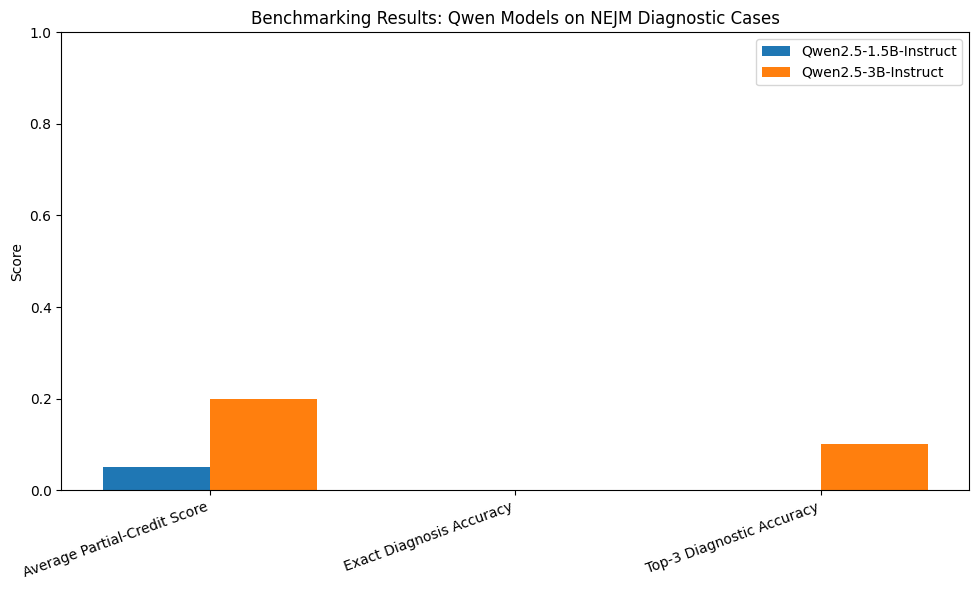

In [20]:
metrics = [
    "Average Partial-Credit Score",
    "Exact Diagnosis Accuracy",
    "Top-3 Diagnostic Accuracy"
]

model1_values = results_summary.loc[0, metrics].values.astype(float)
model2_values = results_summary.loc[1, metrics].values.astype(float)

x = np.arange(len(metrics))
width = 0.35

model1_label = MODEL_1_NAME.split("/")[-1]
model2_label = MODEL_2_NAME.split("/")[-1]

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, model1_values, width, label=model1_label)
plt.bar(x + width/2, model2_values, width, label=model2_label)

plt.xticks(x, metrics, rotation=20, ha="right")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.title("Benchmarking Results: Qwen Models on NEJM Diagnostic Cases")
plt.legend()
plt.tight_layout()

plt.savefig("qwen_benchmarking_chart.png", dpi=300)
plt.show()

In [21]:
files.download("qwen_benchmarking_chart.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [22]:
model1_label = MODEL_1_NAME.split("/")[-1]
model2_label = MODEL_2_NAME.split("/")[-1]

score_distribution = pd.DataFrame({
    "Score": [0, 0.5, 1],
    f"{model1_label} Count": [
        (scored_df["model1_score"] == 0).sum(),
        (scored_df["model1_score"] == 0.5).sum(),
        (scored_df["model1_score"] == 1).sum()
    ],
    f"{model2_label} Count": [
        (scored_df["model2_score"] == 0).sum(),
        (scored_df["model2_score"] == 0.5).sum(),
        (scored_df["model2_score"] == 1).sum()
    ]
})

score_distribution

,Score,Qwen2.5-1.5B-Instruct Count,Qwen2.5-3B-Instruct Count
0,0.0,9,6
1,0.5,1,4
2,1.0,0,0


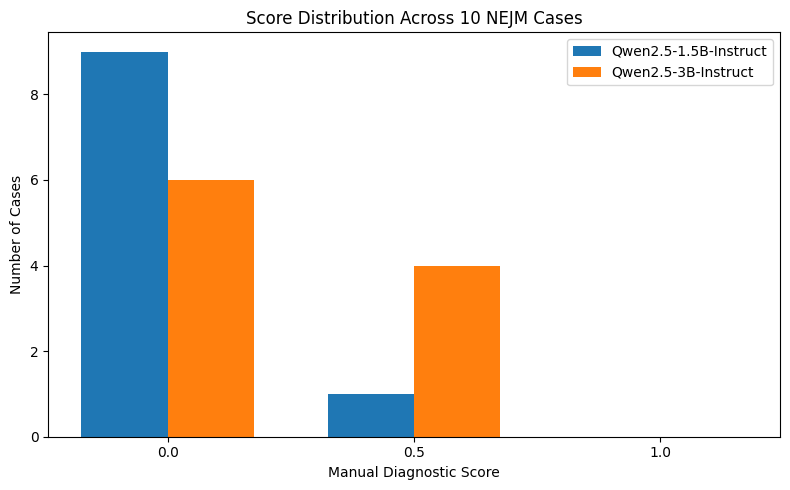

In [23]:
x = np.arange(len(score_distribution["Score"]))
width = 0.35

model1_col = f"{model1_label} Count"
model2_col = f"{model2_label} Count"

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, score_distribution[model1_col], width, label=model1_label)
plt.bar(x + width/2, score_distribution[model2_col], width, label=model2_label)

plt.xticks(x, score_distribution["Score"])
plt.xlabel("Manual Diagnostic Score")
plt.ylabel("Number of Cases")
plt.title("Score Distribution Across 10 NEJM Cases")
plt.legend()
plt.tight_layout()

plt.savefig("qwen_score_distribution.png", dpi=300)
plt.show()

In [24]:
files.download("qwen_score_distribution.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
scored_df["score_difference_model2_minus_model1"] = (
    scored_df["model2_score"] - scored_df["model1_score"]
)

improved_cases = scored_df[scored_df["score_difference_model2_minus_model1"] > 0]
same_cases = scored_df[scored_df["score_difference_model2_minus_model1"] == 0]
worse_cases = scored_df[scored_df["score_difference_model2_minus_model1"] < 0]

print("Cases where Model 2 improved:", len(improved_cases))
print("Cases where both models were same:", len(same_cases))
print("Cases where Model 2 was worse:", len(worse_cases))

improved_cases[
    [
        "case_id",
        "correct_diagnosis",
        "model1_score",
        "model2_score",
        "qualitative_notes"
    ]
]

Cases where Model 2 improved: 3
Cases where both models were same: 7
Cases where Model 2 was worse: 0


,case_id,correct_diagnosis,model1_score,model2_score,qualitative_notes
1,Case 2,Pulmonary histoplasmosis,0.0,0.5,Model 1 predicted pulmonary sarcoidosis. Model...
2,Case 3,Human immunodeficiency virus type 2 infection ...,0.0,0.5,Model 1 predicted hemorrhagic stroke. Model 2 ...
8,Case 9,Granulomatosis with polyangiitis,0.0,0.5,Model 1 predicted pulmonary embolism. Model 2 ...


In [26]:
final_results_table = scored_df[
    [
        "case_id",
        "NEJM_link",
        "correct_diagnosis",
        "diagnosis_short_label",
        "model1_name",
        "model1_output",
        "model1_score",
        "model1_top3_correct",
        "model2_name",
        "model2_output",
        "model2_score",
        "model2_top3_correct",
        "score_difference_model2_minus_model1",
        "qualitative_notes"
    ]
]

final_results_table.to_csv("qwen_final_detailed_benchmarking_results.csv", index=False)
files.download("qwen_final_detailed_benchmarking_results.csv")

final_results_table

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,case_id,NEJM_link,correct_diagnosis,diagnosis_short_label,model1_name,model1_output,model1_score,model1_top3_correct,model2_name,model2_output,model2_score,model2_top3_correct,score_difference_model2_minus_model1,qualitative_notes
0,Case 1,https://www.nejm.org/doi/full/10.1056/NEJMcpc2...,Erysipelothrix rhusiopathiae infection,Cutaneous Erysipelothrix rhusiopathiae infecti...,Qwen/Qwen2.5-1.5B-Instruct,Most likely diagnosis:\nDermatofibrosarcoma pr...,0.0,0,Qwen/Qwen2.5-3B-Instruct,Most likely diagnosis:\nDeep fungal infection ...,0.0,0,0.0,Both Qwen models missed the zoonotic Erysipelo...
1,Case 2,https://www.nejm.org/doi/full/10.1056/NEJMcpc1...,Pulmonary histoplasmosis,Histoplasma capsulatum pulmonary infection / p...,Qwen/Qwen2.5-1.5B-Instruct,Most likely diagnosis:\nPrimary pulmonary tube...,0.0,0,Qwen/Qwen2.5-3B-Instruct,Most likely diagnosis:\nPulmonary tuberculosis...,0.5,0,0.5,Model 1 predicted pulmonary sarcoidosis. Model...
2,Case 3,https://www.nejm.org/doi/full/10.1056/NEJMcpc1...,Human immunodeficiency virus type 2 infection ...,HIV-2 infection with cerebral toxoplasmosis,Qwen/Qwen2.5-1.5B-Instruct,Most likely diagnosis:\nHIV encephalopathy\n\n...,0.0,0,Qwen/Qwen2.5-3B-Instruct,Most likely diagnosis:\nProgressive Multifocal...,0.5,0,0.5,Model 1 predicted hemorrhagic stroke. Model 2 ...
3,Case 4,https://www.nejm.org/doi/full/10.1056/NEJMcpc2...,Borrelia miyamotoi infection,Borrelia miyamotoi meningoencephalitis,Qwen/Qwen2.5-1.5B-Instruct,Most likely diagnosis:\nPrimary Sjögren's synd...,0.0,0,Qwen/Qwen2.5-3B-Instruct,Most likely diagnosis:\nSubacute sclerosing pa...,0.0,0,0.0,Both Qwen models missed Borrelia miyamotoi inf...
4,Case 5,https://www.nejm.org/doi/full/10.1056/NEJMcpc2...,Vitamin D deficiency,Nutritional vitamin D deficiency with rickets ...,Qwen/Qwen2.5-1.5B-Instruct,Most likely diagnosis:\nRickets\n\nTop 3 diffe...,0.5,0,Qwen/Qwen2.5-3B-Instruct,Most likely diagnosis:\nEhlers-Danlos Syndrome...,0.5,1,0.0,Model 1 recognised a rickets-type process but ...
5,Case 6,https://www.nejm.org/doi/full/10.1056/NEJMcpc2...,Systemic primary amyloidosis,Systemic AL amyloidosis / primary amyloidosis,Qwen/Qwen2.5-1.5B-Instruct,Most likely diagnosis:\nOptic nerve glioma\n\n...,0.0,0,Qwen/Qwen2.5-3B-Instruct,Most likely diagnosis:\nMalignant orbital tumo...,0.0,0,0.0,Both Qwen models missed systemic primary amylo...
6,Case 7,https://www.nejm.org/doi/full/10.1056/NEJMcpc2...,Inflammatory bowel disease (Crohn’s disease),Crohn’s disease,Qwen/Qwen2.5-1.5B-Instruct,Most likely diagnosis:\nLyme disease\n\nTop 3 ...,0.0,0,Qwen/Qwen2.5-3B-Instruct,Most likely diagnosis:\nJuvenile Rheumatoid Ar...,0.0,0,0.0,Both Qwen models missed Crohn's disease and we...
7,Case 8,https://www.nejm.org/doi/full/10.1056/NEJMcpc2...,Aspiration pneumonia,Aspiration pneumonia / diffuse aspiration bron...,Qwen/Qwen2.5-1.5B-Instruct,Most likely diagnosis:\nChronic obstructive pu...,0.0,0,Qwen/Qwen2.5-3B-Instruct,Most likely diagnosis:\nGranulomatous disease ...,0.0,0,0.0,Both Qwen models missed aspiration pneumonia a...
8,Case 9,https://www.nejm.org/doi/full/10.1056/NEJMcpc2...,Granulomatosis with polyangiitis,ANCA-associated vasculitis / granulomatosis wi...,Qwen/Qwen2.5-1.5B-Instruct,Most likely diagnosis:\nPneumonia due to Strep...,0.0,0,Qwen/Qwen2.5-3B-Instruct,Most likely diagnosis:\nAcute Respiratory Dist...,0.5,0,0.5,Model 1 predicted pulmonary embolism. Model 2 ...
9,Case 10,https://www.nejm.org/doi/full/10.1056/NEJMcpc2...,Sarcoidosis,Sarcoidosis with ocular and neurologic involve...,Qwen/Qwen2.5-1.5B-Instruct,Most likely diagnosis:\nMultiple sclerosis (MS...,0.0,0,Qwen/Qwen2.5-3B-Instruct,Most likely diagnosis:\nGuillain-Barré Syndrom...,0.0,0,0.0,Both Qwen models missed sarcoidosis and were d...


In [27]:
if model1_average_score > model2_average_score:
    best_model = MODEL_1_NAME
elif model2_average_score > model1_average_score:
    best_model = MODEL_2_NAME
else:
    best_model = "Both models performed equally by average partial-credit score"

summary_text = f"""
Practical Benchmarking Summary

A small proof-of-concept benchmark was conducted using 10 NEJM clinical challenge cases.
Two open-source instruction-tuned LLMs were compared:

Model 1: {MODEL_1_NAME}
Model 2: {MODEL_2_NAME}

Both models were evaluated using the same structured diagnostic prompt.

{MODEL_1_NAME} achieved:
- Average partial-credit score: {model1_average_score:.2f}
- Exact diagnosis accuracy: {model1_exact_accuracy:.2f}
- Top-3 diagnostic accuracy: {model1_top3_accuracy:.2f}

{MODEL_2_NAME} achieved:
- Average partial-credit score: {model2_average_score:.2f}
- Exact diagnosis accuracy: {model2_exact_accuracy:.2f}
- Top-3 diagnostic accuracy: {model2_top3_accuracy:.2f}

The better-performing model was: {best_model}.

The results show that the larger Qwen2.5-3B-Instruct model performed better than Qwen2.5-1.5B-Instruct on partial-credit scoring.
However, both models achieved 0% exact diagnostic accuracy on the 10 complex NEJM cases.
This suggests that small general-purpose open-source LLMs are not reliable enough for standalone clinical diagnosis.
The models often gave confident but incorrect answers, showing the need for retrieval support, domain-specific adaptation, uncertainty reporting, and human clinician oversight.
"""

print(summary_text)

with open("qwen_practical_benchmarking_summary.txt", "w") as f:
    f.write(summary_text)

files.download("qwen_practical_benchmarking_summary.txt")


Practical Benchmarking Summary

A small proof-of-concept benchmark was conducted using 10 NEJM clinical challenge cases.
Two open-source instruction-tuned LLMs were compared:

Model 1: Qwen/Qwen2.5-1.5B-Instruct
Model 2: Qwen/Qwen2.5-3B-Instruct

Both models were evaluated using the same structured diagnostic prompt.

Qwen/Qwen2.5-1.5B-Instruct achieved:
- Average partial-credit score: 0.05
- Exact diagnosis accuracy: 0.00
- Top-3 diagnostic accuracy: 0.00

Qwen/Qwen2.5-3B-Instruct achieved:
- Average partial-credit score: 0.20
- Exact diagnosis accuracy: 0.00
- Top-3 diagnostic accuracy: 0.10

The better-performing model was: Qwen/Qwen2.5-3B-Instruct.

The results show that the larger Qwen2.5-3B-Instruct model performed better than Qwen2.5-1.5B-Instruct on partial-credit scoring.
However, both models achieved 0% exact diagnostic accuracy on the 10 complex NEJM cases.
This suggests that small general-purpose open-source LLMs are not reliable enough for standalone clinical diagnosis.
T

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [28]:
evidence_checklist = pd.DataFrame({
    "Evidence File": [
        "nejm_cases_combined_task2.csv",
        "checkpoint_after_model1_qwen.csv",
        "qwen_two_model_raw_predictions.csv",
        "qwen_benchmarking_summary.csv",
        "qwen_benchmarking_chart.png",
        "qwen_score_distribution.png",
        "qwen_final_detailed_benchmarking_results.csv",
        "qwen_practical_benchmarking_summary.txt"
    ],
    "Purpose": [
        "Prepared dataset of 10 NEJM clinical challenge cases",
        "Checkpoint after running Qwen2.5-1.5B-Instruct",
        "Raw diagnostic outputs from both Qwen models",
        "Summary of quantitative benchmarking metrics",
        "Graph comparing model performance",
        "Graph showing score distribution",
        "Detailed case-by-case benchmarking table",
        "Report-ready practical benchmarking summary"
    ]
})

evidence_checklist.to_csv("qwen_practical_evidence_checklist.csv", index=False)
files.download("qwen_practical_evidence_checklist.csv")

evidence_checklist

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,Evidence File,Purpose
0,nejm_cases_combined_task2.csv,Prepared dataset of 10 NEJM clinical challenge...
1,checkpoint_after_model1_qwen.csv,Checkpoint after running Qwen2.5-1.5B-Instruct
2,qwen_two_model_raw_predictions.csv,Raw diagnostic outputs from both Qwen models
3,qwen_benchmarking_summary.csv,Summary of quantitative benchmarking metrics
4,qwen_benchmarking_chart.png,Graph comparing model performance
5,qwen_score_distribution.png,Graph showing score distribution
6,qwen_final_detailed_benchmarking_results.csv,Detailed case-by-case benchmarking table
7,qwen_practical_benchmarking_summary.txt,Report-ready practical benchmarking summary


In [29]:
!pip install -q datasets

In [30]:
from datasets import load_dataset
import pandas as pd
import numpy as np
import re
from google.colab import files

medmcqa_dataset = load_dataset("openlifescienceai/medmcqa", split="validation")

print(medmcqa_dataset)
print(medmcqa_dataset.column_names)

README.md:   0%|          | 0.00/10.7k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/85.9M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/936k [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/1.48M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/182822 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/6150 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/4183 [00:00<?, ? examples/s]

Dataset({
    features: ['id', 'question', 'opa', 'opb', 'opc', 'opd', 'cop', 'choice_type', 'exp', 'subject_name', 'topic_name'],
    num_rows: 4183
})
['id', 'question', 'opa', 'opb', 'opc', 'opd', 'cop', 'choice_type', 'exp', 'subject_name', 'topic_name']


In [31]:
medmcqa_sample = medmcqa_dataset.shuffle(seed=42).select(range(20))
medmcqa_df = pd.DataFrame(medmcqa_sample)

medmcqa_df = medmcqa_df[
    [
        "id",
        "question",
        "opa",
        "opb",
        "opc",
        "opd",
        "cop",
        "subject_name",
        "topic_name"
    ]
].copy()

option_map = {
    0: "A",
    1: "B",
    2: "C",
    3: "D"
}

medmcqa_df["correct_option"] = medmcqa_df["cop"].map(option_map)

medmcqa_df.head()

,id,question,opa,opb,opc,opd,cop,subject_name,topic_name,correct_option
0,39c933d9-6014-4f3d-9b81-cb67eb2ec6b9,Amount of heat that is required to change boil...,Latent Heat of vaporization,Latent Heat of sublimation,Latent Heat of condensation,Latent heat of fusion,0,Dental,None,A
1,0d3453ee-77ef-400b-9e64-4ff5b6cbfcc8,"In Ricketts esthetic plane, lower lip rests:",1 mm anterior to plane,On the plane,2 mm posterior to plane,1 mm posterior to plane,2,Dental,None,C
2,4080f3a3-a88c-4bcb-a8a3-2add0483fca0,Which score is used for wound infection,Glasgow coma scale,Southampton score,Apgar score,SIRS score,1,Surgery,None,B
3,a45d9322-2e84-4b76-aa18-537bd856d604,All of the following are true about Ifosfamide...,It is nitrogen mustard,Metabolised by CYP3A4 to form active metabolite,Chloracetaldehyde is active form,Less neurotoxic than cyclophosphamide,3,Pharmacology,None,D
4,5e7cb3e3-57f6-4748-96dd-0b8f6e2fa902,All of the following are true regarding tonsil...,Extracapsular approach is best for cold approach,Sleep apnea is an indication,Adenoids should also be removed if significant...,Cricothyroid region is high and anterior in ch...,0,ENT,None,A


In [32]:
medmcqa_df.to_csv("dataset2_medmcqa_sample_20_questions.csv", index=False)
files.download("dataset2_medmcqa_sample_20_questions.csv")

medmcqa_df.head()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,id,question,opa,opb,opc,opd,cop,subject_name,topic_name,correct_option
0,39c933d9-6014-4f3d-9b81-cb67eb2ec6b9,Amount of heat that is required to change boil...,Latent Heat of vaporization,Latent Heat of sublimation,Latent Heat of condensation,Latent heat of fusion,0,Dental,None,A
1,0d3453ee-77ef-400b-9e64-4ff5b6cbfcc8,"In Ricketts esthetic plane, lower lip rests:",1 mm anterior to plane,On the plane,2 mm posterior to plane,1 mm posterior to plane,2,Dental,None,C
2,4080f3a3-a88c-4bcb-a8a3-2add0483fca0,Which score is used for wound infection,Glasgow coma scale,Southampton score,Apgar score,SIRS score,1,Surgery,None,B
3,a45d9322-2e84-4b76-aa18-537bd856d604,All of the following are true about Ifosfamide...,It is nitrogen mustard,Metabolised by CYP3A4 to form active metabolite,Chloracetaldehyde is active form,Less neurotoxic than cyclophosphamide,3,Pharmacology,None,D
4,5e7cb3e3-57f6-4748-96dd-0b8f6e2fa902,All of the following are true regarding tonsil...,Extracapsular approach is best for cold approach,Sleep apnea is an indication,Adenoids should also be removed if significant...,Cricothyroid region is high and anterior in ch...,0,ENT,None,A


In [33]:
def build_medmcqa_prompt(row):
    prompt = f"""
You are completing an academic medical reasoning benchmark.

Choose the single best answer to the following medical multiple-choice question.

Return only one option letter: A, B, C, or D.

Question:
{row["question"]}

Options:
A. {row["opa"]}
B. {row["opb"]}
C. {row["opc"]}
D. {row["opd"]}
"""
    return prompt

In [34]:
def extract_option_letter(output):
    output = str(output).strip().upper()

    match = re.search(r"\b[A-D]\b", output)
    if match:
        return match.group(0)

    return "INVALID"

In [35]:
def run_model_on_medmcqa(model_name, data):
    tokenizer, model = load_causal_llm(model_name)

    outputs = []
    predicted_options = []

    for index, row in data.iterrows():
        print(f"Running {model_name} on MedMCQA item {index + 1}/{len(data)}...")

        prompt = build_medmcqa_prompt(row)
        response = generate_diagnosis_direct(
            tokenizer,
            model,
            prompt,
            max_new_tokens=20
        )

        predicted_option = extract_option_letter(response)

        outputs.append(response)
        predicted_options.append(predicted_option)

    del tokenizer
    del model
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return outputs, predicted_options

In [38]:
medmcqa_results = medmcqa_df.copy()

medmcqa_results["model1_name"] = MODEL_1_NAME
medmcqa_results["model1_output"], medmcqa_results["model1_predicted_option"] = run_model_on_medmcqa(
    MODEL_1_NAME,
    medmcqa_df
)

medmcqa_results["model2_name"] = MODEL_2_NAME
medmcqa_results["model2_output"], medmcqa_results["model2_predicted_option"] = run_model_on_medmcqa(
    MODEL_2_NAME,
    medmcqa_df
)

medmcqa_results.head()

Loading model: Qwen/Qwen2.5-1.5B-Instruct


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Running Qwen/Qwen2.5-1.5B-Instruct on MedMCQA item 1/20...
Running Qwen/Qwen2.5-1.5B-Instruct on MedMCQA item 2/20...
Running Qwen/Qwen2.5-1.5B-Instruct on MedMCQA item 3/20...
Running Qwen/Qwen2.5-1.5B-Instruct on MedMCQA item 4/20...
Running Qwen/Qwen2.5-1.5B-Instruct on MedMCQA item 5/20...
Running Qwen/Qwen2.5-1.5B-Instruct on MedMCQA item 6/20...
Running Qwen/Qwen2.5-1.5B-Instruct on MedMCQA item 7/20...
Running Qwen/Qwen2.5-1.5B-Instruct on MedMCQA item 8/20...
Running Qwen/Qwen2.5-1.5B-Instruct on MedMCQA item 9/20...
Running Qwen/Qwen2.5-1.5B-Instruct on MedMCQA item 10/20...
Running Qwen/Qwen2.5-1.5B-Instruct on MedMCQA item 11/20...
Running Qwen/Qwen2.5-1.5B-Instruct on MedMCQA item 12/20...
Running Qwen/Qwen2.5-1.5B-Instruct on MedMCQA item 13/20...
Running Qwen/Qwen2.5-1.5B-Instruct on MedMCQA item 14/20...
Running Qwen/Qwen2.5-1.5B-Instruct on MedMCQA item 15/20...
Running Qwen/Qwen2.5-1.5B-Instruct on MedMCQA item 16/20...
Running Qwen/Qwen2.5-1.5B-Instruct on MedMCQA ite

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

Running Qwen/Qwen2.5-3B-Instruct on MedMCQA item 1/20...
Running Qwen/Qwen2.5-3B-Instruct on MedMCQA item 2/20...
Running Qwen/Qwen2.5-3B-Instruct on MedMCQA item 3/20...
Running Qwen/Qwen2.5-3B-Instruct on MedMCQA item 4/20...
Running Qwen/Qwen2.5-3B-Instruct on MedMCQA item 5/20...
Running Qwen/Qwen2.5-3B-Instruct on MedMCQA item 6/20...
Running Qwen/Qwen2.5-3B-Instruct on MedMCQA item 7/20...
Running Qwen/Qwen2.5-3B-Instruct on MedMCQA item 8/20...
Running Qwen/Qwen2.5-3B-Instruct on MedMCQA item 9/20...
Running Qwen/Qwen2.5-3B-Instruct on MedMCQA item 10/20...
Running Qwen/Qwen2.5-3B-Instruct on MedMCQA item 11/20...
Running Qwen/Qwen2.5-3B-Instruct on MedMCQA item 12/20...
Running Qwen/Qwen2.5-3B-Instruct on MedMCQA item 13/20...
Running Qwen/Qwen2.5-3B-Instruct on MedMCQA item 14/20...
Running Qwen/Qwen2.5-3B-Instruct on MedMCQA item 15/20...
Running Qwen/Qwen2.5-3B-Instruct on MedMCQA item 16/20...
Running Qwen/Qwen2.5-3B-Instruct on MedMCQA item 17/20...
Running Qwen/Qwen2.5-3B

,id,question,opa,opb,opc,opd,cop,subject_name,topic_name,correct_option,model1_name,model1_output,model1_predicted_option,model2_name,model2_output,model2_predicted_option
0,39c933d9-6014-4f3d-9b81-cb67eb2ec6b9,Amount of heat that is required to change boil...,Latent Heat of vaporization,Latent Heat of sublimation,Latent Heat of condensation,Latent heat of fusion,0,Dental,None,A,Qwen/Qwen2.5-1.5B-Instruct,A,A,Qwen/Qwen2.5-3B-Instruct,A. Latent Heat of vaporization,A
1,0d3453ee-77ef-400b-9e64-4ff5b6cbfcc8,"In Ricketts esthetic plane, lower lip rests:",1 mm anterior to plane,On the plane,2 mm posterior to plane,1 mm posterior to plane,2,Dental,None,C,Qwen/Qwen2.5-1.5B-Instruct,B,B,Qwen/Qwen2.5-3B-Instruct,B,B
2,4080f3a3-a88c-4bcb-a8a3-2add0483fca0,Which score is used for wound infection,Glasgow coma scale,Southampton score,Apgar score,SIRS score,1,Surgery,None,B,Qwen/Qwen2.5-1.5B-Instruct,B,B,Qwen/Qwen2.5-3B-Instruct,B,B
3,a45d9322-2e84-4b76-aa18-537bd856d604,All of the following are true about Ifosfamide...,It is nitrogen mustard,Metabolised by CYP3A4 to form active metabolite,Chloracetaldehyde is active form,Less neurotoxic than cyclophosphamide,3,Pharmacology,None,D,Qwen/Qwen2.5-1.5B-Instruct,C,C,Qwen/Qwen2.5-3B-Instruct,A,A
4,5e7cb3e3-57f6-4748-96dd-0b8f6e2fa902,All of the following are true regarding tonsil...,Extracapsular approach is best for cold approach,Sleep apnea is an indication,Adenoids should also be removed if significant...,Cricothyroid region is high and anterior in ch...,0,ENT,None,A,Qwen/Qwen2.5-1.5B-Instruct,A,A,Qwen/Qwen2.5-3B-Instruct,A,A


In [39]:
medmcqa_results["model1_correct"] = (
    medmcqa_results["model1_predicted_option"] == medmcqa_results["correct_option"]
).astype(int)

medmcqa_results["model2_correct"] = (
    medmcqa_results["model2_predicted_option"] == medmcqa_results["correct_option"]
).astype(int)

model1_medmcqa_accuracy = medmcqa_results["model1_correct"].mean()
model2_medmcqa_accuracy = medmcqa_results["model2_correct"].mean()

medmcqa_summary = pd.DataFrame({
    "Dataset": ["MedMCQA", "MedMCQA"],
    "Model": [MODEL_1_NAME, MODEL_2_NAME],
    "Number of Questions": [len(medmcqa_results), len(medmcqa_results)],
    "Accuracy": [model1_medmcqa_accuracy, model2_medmcqa_accuracy]
})

medmcqa_summary

,Dataset,Model,Number of Questions,Accuracy
0,MedMCQA,Qwen/Qwen2.5-1.5B-Instruct,20,0.5
1,MedMCQA,Qwen/Qwen2.5-3B-Instruct,20,0.7


In [40]:
medmcqa_results.to_csv("dataset2_medmcqa_qwen_results.csv", index=False)
medmcqa_summary.to_csv("dataset2_medmcqa_summary.csv", index=False)

files.download("dataset2_medmcqa_qwen_results.csv")
files.download("dataset2_medmcqa_summary.csv")

medmcqa_summary

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,Dataset,Model,Number of Questions,Accuracy
0,MedMCQA,Qwen/Qwen2.5-1.5B-Instruct,20,0.5
1,MedMCQA,Qwen/Qwen2.5-3B-Instruct,20,0.7


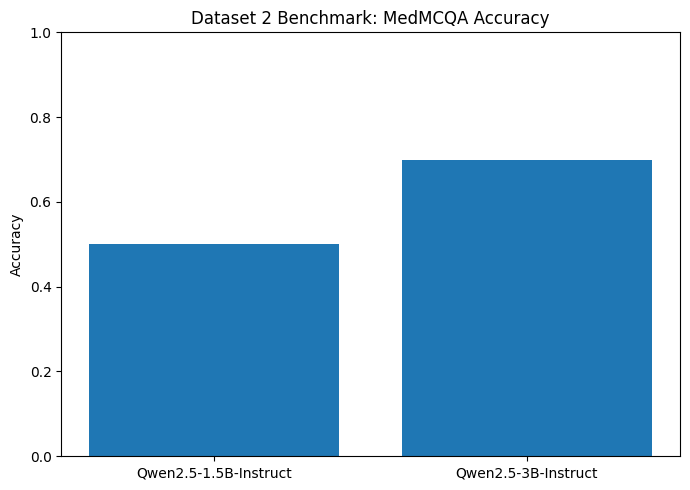

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [41]:
model_labels = [
    MODEL_1_NAME.split("/")[-1],
    MODEL_2_NAME.split("/")[-1]
]

accuracies = [
    model1_medmcqa_accuracy,
    model2_medmcqa_accuracy
]

plt.figure(figsize=(7, 5))
plt.bar(model_labels, accuracies)
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.title("Dataset 2 Benchmark: MedMCQA Accuracy")
plt.tight_layout()

plt.savefig("dataset2_medmcqa_accuracy_chart.png", dpi=300)
plt.show()

files.download("dataset2_medmcqa_accuracy_chart.png")